In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 경로 설정
import os 
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12,6)

# 시드 설정
np.random.seed(42)

print('-' * 60)
print('라이브러리 로드 완료')
print('한글 폰트 설정 완료!')
print('-'* 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [2]:
# 현재 작업 디렉토리(notebooks)의 부모 디렉토리(root)를 경로에 추가
os.chdir(os.path.abspath('..'))
print(os.getcwd())

df = pd.read_csv('data/2025_Airbnb_NYC_listings.csv').drop(columns = 'Unnamed: 0')
df.head()

c:\Users\chanhyeok\Desktop\lucky7\airbnb_price_prediction


,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,36121,city scrape,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",I’m an urban planner working for an internatio...,NaN,NaN,NaN,f,Prospect Heights,1.0,3.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",$200.00,90,365,90.0,90.0,365.0,365.0,90.0,365.0,NaN,t,27,57,87,362,2025-03-03,9,0,0,301,0,0,0.0,2010-12-11,2013-05-10,4.88,5.00,4.80,5.00,5.00,5.00,5.00,NaN,f,1,0,1,0,0.05
1,36647,city scrape,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",NaN,NaN,NaN,100%,f,East Harlem,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1 private bath,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",$82.00,30,999,30.0,30.0,999.0,999.0,30.0,999.0,NaN,t,0,0,0,204,2025-03-03,102,0,0,143,0,0,0.0,2010-10-04,2023-12-09,4.77,4.82,4.76,4.88,4.90,4.38,4.71,NaN,f,1,0,1,0,0.58
2,38663,city scrape,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",I am a lawyer and work as an executive at an a...,within a few hours,100%,40%,f,Boerum Hill,1.0,3.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",$765.00,3,60,3.0,3.0,60.0,60.0,3.0,60.0,NaN,t,30,49,66,326,2025-03-02,43,0,0,267,0,0,0.0,2012-07-09,2023-08-30,4.70,4.83,4.52,4.88,4.88,4.86,4.62,OSE-STRREG-0001784,f,1,0,1,0,0.28
3,38833,city scrape,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,West Harlem is now packed with great restauran...,166532,Matthew,2010-07-14,"New York, NY",I have been a New Yorker for a long time\n and...,within an hour,100%,97%,t,Harlem,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",$139.00,2,45,2.0,2.0,1125.0,1125.0,2.0,1125.0,NaN,t,7,18,25,25,2025-03-03,241,42,3,25,43,255,35445.0,2010-08-28,2025-02-21,4.85,4.87,4.50,4.96,4.96,4.79,4.82,OSE-STRREG-0000476,

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 72 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            22308 non-null  int64  
 1   source                                        22308 non-null  str    
 2   name                                          22308 non-null  str    
 3   description                                   21903 non-null  str    
 4   neighborhood_overview                         12262 non-null  str    
 5   host_id                                       22308 non-null  int64  
 6   host_name                                     22288 non-null  str    
 7   host_since                                    22288 non-null  str    
 8   host_location                                 17025 non-null  str    
 9   host_about                                    13391 non-null  str    
 1

In [4]:
# 1차 전처리 columns
drop_cols = ['source','calendar_updated','calendar_last_scraped']

convert_tf_cols = ['host_is_superhost', 'host_has_profile_pic',
                'host_identity_verified','has_availability',
                'instant_bookable']

df['price'] = df['price'].str.replace('$','').str.replace(',','').astype('float')

df['host_since'] = pd.to_datetime(df['host_since'])

# 처리 함수
def convert_tf(df, cols):
    for col in cols:
        df[col] = df[col].map({'t':True, 'f':False}).astype('boolean')

    return df

df_cleaned = convert_tf(df, convert_tf_cols)
df_cleaned = df_cleaned.drop(columns = drop_cols)

In [5]:
df_cleaned.shape

(22308, 69)

In [ ]:
df_cleaned['number_of_reviews'].quantile(0.9)
df_cleaned['number_of_reviews'].dtypes
df_cleaned['number_of_reviews'].sort_values(ascending=False).head(20)


# 전체 22308 행 중 6798개가 0, 상위 10퍼센트가 100개
# 평균 34 , 표준편차 76

dtype('int64')

In [34]:
df_cleaned['host_id'].duplicated().sum()
df_cleaned['host_id'].dtypes
#결측치 X
(df_cleaned['host_id'].value_counts() == 1094).sum()
#2개 이상 운영 중인 호스트 수 2601명


np.int64(1)

In [38]:
df_cleaned[df_cleaned['host_name'].isna()]
df_cleaned[df_cleaned['host_name'].isna()].count()
#df_cleaned['host_name'].describe




id                                              20
name                                            20
description                                     20
neighborhood_overview                           10
host_id                                         20
host_name                                        0
host_since                                       0
host_location                                    0
host_about                                       0
host_response_time                               0
host_response_rate                               0
host_acceptance_rate                             0
host_is_superhost                               20
host_neighbourhood                               0
host_listings_count                              0
host_total_listings_count                        0
host_verifications                               0
host_has_profile_pic                             0
host_identity_verified                           0
neighbourhood                  

In [ ]:
df_cleaned['host_location'][(df_cleaned['host_location'].str.endswith('NY'))].count()
df_cleaned['host_location']
df_cleaned['host_location'].value_counts()

host_location
New York, NY                   13441
New York, United States         1716
Dubai, United Arab Emirates      312
United States                    147
Los Angeles, CA                   61
                               ...  
Knoxville, TN                      1
Shokan, NY                         1
Havelock, NC                       1
Coral Gables, FL                   1
Charleston, SC                     1
Name: count, Length: 421, dtype: int64

In [ ]:
df_cleaned['host_about'].describe()

count                                                 13391
unique                                                 5804
top       We’re Blueground, a global proptech company wi...
freq                                                   1094
Name: host_about, dtype: object

In [13]:
df_cleaned['host_response_rate'].isna().sum()

np.int64(4393)

In [14]:
df_cleaned['host_response_time'].value_counts()


host_response_time
within an hour        11645
within a few hours     3439
within a day           1957
a few days or more      874
Name: count, dtype: int64

In [15]:
df_cleaned['host_acceptance_rate'].isna().sum()

np.int64(3466)

In [16]:
df_cleaned['host_neighbourhood'].describe()

count                  17578
unique                   446
top       Bedford-Stuyvesant
freq                    1138
Name: host_neighbourhood, dtype: object

In [17]:
## 전처리

df_cleaned['host_response_rate'] = df_cleaned['host_response_rate'].str.replace('%','').astype('float')
df_cleaned['host_acceptance_rate'] = df_cleaned['host_acceptance_rate'].str.replace('%','').astype('float')

count    17915.000000
mean        93.042311
std         19.289099
min          0.000000
25%         99.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: host_response_rate, dtype: float64

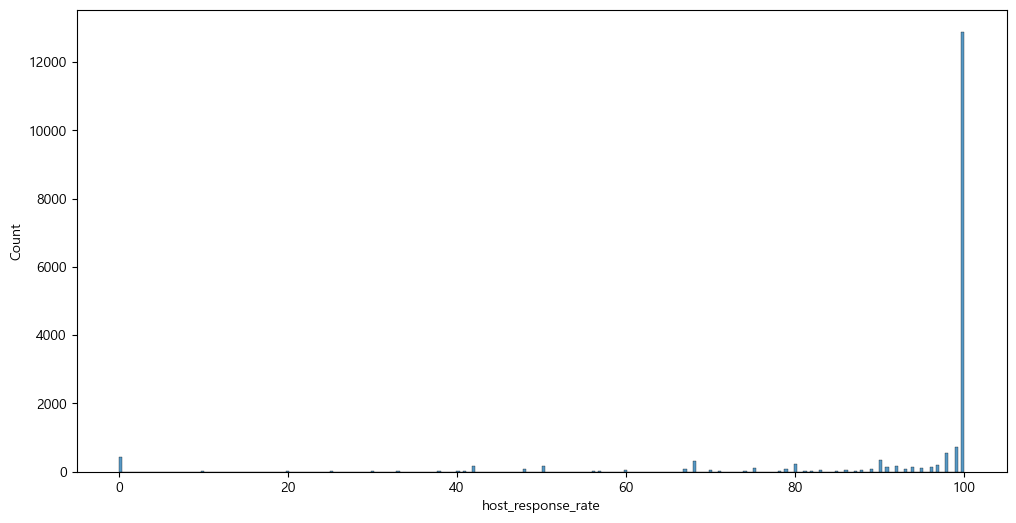

In [23]:
sns.histplot(df_cleaned['host_response_rate'])
df_cleaned['host_response_rate'].describe()

<Axes: xlabel='host_acceptance_rate', ylabel='Count'>

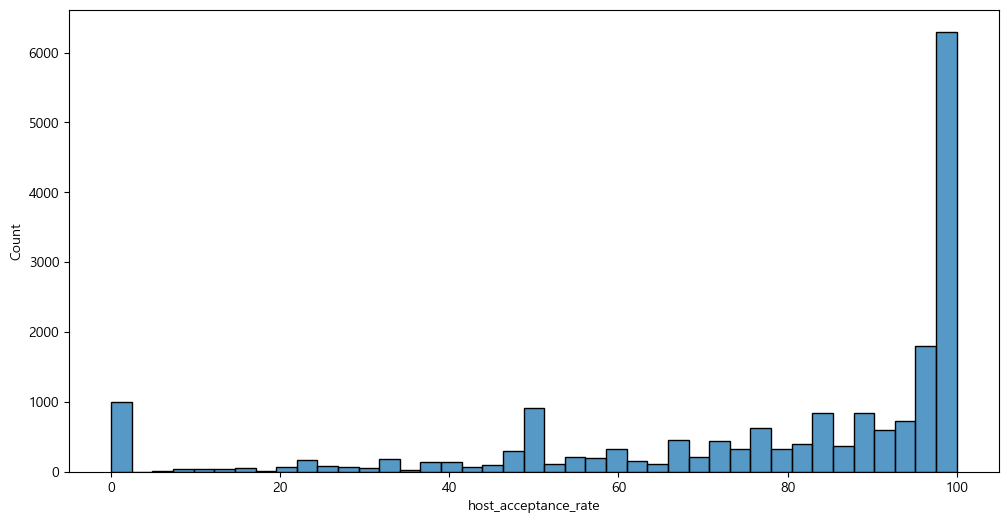

In [35]:
df_cleaned['host_acceptance_rate'].describe()
sns.histplot(df_cleaned['host_acceptance_rate'])

In [32]:
df_cleaned['host_is_superhost']

0        False
1        False
2        False
3         True
4         True
         ...  
22303    False
22304     True
22305    False
22306    False
22307     True
Name: host_is_superhost, Length: 22308, dtype: boolean